# AGENTS026 — Remediation Planning & Action Executor
**pydantic-ai orchestrated agents · typed RCA → Action schemas · mock K8s infra APIs · full audit trail**

Pipeline:
```
Live Anomalies
     ↓
RemediationPlanningAgent (pydantic-ai + Qwen3-30B)
     ↓  RemediationPlan (typed schema)
Policy Gate  →  HITL if blast=critical
     ↓
ActionExecutorAgent  →  Mock Infra APIs
     ↓
PostIncidentReporter  →  Markdown report + KB update
     ↓
Streamlit Tab 17
```

- Cell 1: Install pydantic-ai + imports
- Cell 2: Typed schemas (RCAResult, Action, RemediationPlan)
- Cell 3: Mock infra API library
- Cell 4: RemediationPlanningAgent (pydantic-ai)
- Cell 5: ActionExecutorAgent
- Cell 6: PostIncidentReporter
- Cell 7: Full orchestrated pipeline run
- Cell 8: Results dashboard

In [5]:
# ── CELL 1 FIX v3 — auto-detects pydantic-ai version ─────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pydantic-ai-slim", "-q"], check=True)

# Check what version installed
import pydantic_ai
print(f"pydantic-ai version: {pydantic_ai.__version__}")

import json, time, uuid, requests
from datetime import datetime, timezone
from pathlib import Path
from typing import Literal, Optional
from enum import Enum
import pandas as pd
import numpy as np
from pydantic import BaseModel, Field
from openai import AsyncOpenAI, OpenAI
from pydantic_ai import Agent

# Auto-detect correct model class
try:
    from pydantic_ai.models.openai import OpenAIChatModel
    pydantic_model = OpenAIChatModel(
        "Qwen3-30B-A3B",
        openai_client=AsyncOpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")
    )
    print("Using OpenAIChatModel")
except Exception as e1:
    print(f"OpenAIChatModel failed: {e1}")
    try:
        from pydantic_ai.models.openai import OpenAIModel
        pydantic_model = OpenAIModel(
            "Qwen3-30B-A3B",
            openai_client=AsyncOpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")
        )
        print("Using OpenAIModel with openai_client")
    except Exception as e2:
        print(f"openai_client failed: {e2} — falling back to provider pattern")
        from pydantic_ai.providers.openai import OpenAIProvider
        from pydantic_ai.models.openai import OpenAIModel
        pydantic_model = OpenAIModel(
            "Qwen3-30B-A3B",
            provider=OpenAIProvider(
                base_url="http://localhost:8000/v1",
                api_key="abc-123"
            )
        )
        print("Using OpenAIModel with provider")

raw_llm = OpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")

# ── Paths ──────────────────────────────────────────────────────────────────
BASE             = Path("/workspace/shared")
METRICS_CSV      = BASE / "minicluster" / "live_metrics.csv"
HITL_FILE        = BASE / "hitl_queue.jsonl"
AUDIT_FILE       = BASE / "audit_log.jsonl"
REMEDIATION_FILE = BASE / "remediation_plans.jsonl"
REPORTS_DIR      = BASE / "incident_reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SERVICES   = {"payments": 7001, "auth": 7002, "checkout": 7003, "fraud": 7004}
THRESHOLDS = {"cpu_utilization": 70.0, "latency_p95_ms": 500.0,
              "error_rate": 0.05, "mem_mb": 1800.0}

def ts(): return datetime.now(timezone.utc).isoformat()
def write_log(path, event):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as f: f.write(json.dumps(event, default=str) + "\n")

print(f"\n✅ Cell 1 ready")
try:
    print(f"   vLLM: {[m.id for m in raw_llm.models.list().data]}")
except Exception as e:
    print(f"   ⚠️ vLLM: {e}")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
/tmp/ipykernel_11143/3093528563.py:33: DeprecationWarning: `OpenAIModel` was renamed to `OpenAIChatModel` to clearly distinguish it from `OpenAIResponsesModel` which uses OpenAI's newer Responses API. Use that unless you're using an OpenAI Chat Completions-compatible API, or require a feature that the Responses API doesn't support yet like audio.
  pydantic_model = OpenAIModel(


pydantic-ai version: 1.107.0
OpenAIChatModel failed: OpenAIChatModel.__init__() got an unexpected keyword argument 'openai_client'
openai_client failed: OpenAIChatModel.__init__() got an unexpected keyword argument 'openai_client' — falling back to provider pattern
Using OpenAIModel with provider


/tmp/ipykernel_11143/3093528563.py:42: DeprecationWarning: `OpenAIModel` was renamed to `OpenAIChatModel` to clearly distinguish it from `OpenAIResponsesModel` which uses OpenAI's newer Responses API. Use that unless you're using an OpenAI Chat Completions-compatible API, or require a feature that the Responses API doesn't support yet like audio.
  pydantic_model = OpenAIModel(



✅ Cell 1 ready
   vLLM: ['Qwen3-30B-A3B']


In [6]:
# ── Cell 2: Typed schemas ─────────────────────────────────────────────────

class SeverityLevel(str, Enum):
    LOW      = "LOW"
    MEDIUM   = "MEDIUM"
    HIGH     = "HIGH"
    CRITICAL = "CRITICAL"

class BlastRadius(str, Enum):
    LOW      = "low"
    MEDIUM   = "medium"
    HIGH     = "high"
    CRITICAL = "critical"

class ActionType(str, Enum):
    RESTART_SERVICE    = "restart_service"
    SCALE_REPLICAS     = "scale_replicas"
    CIRCUIT_BREAKER    = "circuit_breaker_open"
    CLEAR_CACHE        = "clear_cache"
    RATE_LIMIT         = "rate_limit_ingress"
    INCREASE_TIMEOUT   = "increase_timeout"
    DRAIN_NODE         = "drain_node"
    ROLLBACK           = "rollback_deployment"
    FAILOVER           = "failover_to_backup"
    CLEAR_FAULT        = "clear_fault_injection"
    ALERT_ONCALL       = "alert_oncall_team"

class AnomalySignal(BaseModel):
    service   : str
    metric    : str
    value     : float
    threshold : float
    severity  : str
    z_score   : float = 0.0

class RCAResult(BaseModel):
    incident_id          : str
    root_cause_hypothesis: str   = Field(description="Most likely root cause in one sentence")
    impacted_components  : list[str] = Field(description="List of affected service names")
    probable_trigger     : str   = Field(description="What likely triggered the incident")
    evidence_refs        : list[str] = Field(description="Evidence references e.g. 'payments.latency=820ms'")
    confidence           : float = Field(ge=0.0, le=1.0, description="Confidence score 0-1")
    severity             : SeverityLevel
    estimated_mttr_mins  : int   = Field(description="Estimated minutes to resolve")

class Action(BaseModel):
    action_id      : str = Field(default_factory=lambda: f"ACT-{uuid.uuid4().hex[:8].upper()}")
    action_type    : ActionType
    target_service : str
    parameters     : dict = Field(default_factory=dict, description="Action parameters e.g. replicas=3")
    preconditions  : list[str] = Field(default_factory=list, description="Must be true before executing")
    post_checks    : list[str] = Field(default_factory=list, description="Verify success after executing")
    requires_approval: bool = Field(description="True if HITL approval required")
    blast_radius   : BlastRadius
    rationale      : str  = Field(description="Why this action addresses the root cause")
    priority       : int  = Field(ge=1, le=10, description="Execution order priority (1=first)")
    estimated_duration_secs: int = 30

class RemediationPlan(BaseModel):
    plan_id       : str = Field(default_factory=lambda: f"PLAN-{uuid.uuid4().hex[:8].upper()}")
    incident_id   : str
    rca_summary   : str
    actions       : list[Action] = Field(description="Ordered remediation actions")
    rollback_plan : str = Field(description="How to rollback if actions make things worse")
    success_criteria: list[str] = Field(description="Measurable criteria to confirm resolution")
    estimated_total_mins: int

class ActionResult(BaseModel):
    action_id  : str
    action_type: str
    target     : str
    status     : Literal["SUCCESS", "FAILED", "SKIPPED", "HITL_PENDING"]
    api_response: dict = Field(default_factory=dict)
    duration_ms : int  = 0
    error       : Optional[str] = None
    executed_at : str  = Field(default_factory=ts)

class IncidentReport(BaseModel):
    report_id     : str = Field(default_factory=lambda: f"RPT-{uuid.uuid4().hex[:8].upper()}")
    incident_id   : str
    plan_id       : str
    title         : str
    severity      : SeverityLevel
    timeline      : list[dict]
    rca           : RCAResult
    actions_taken : list[ActionResult]
    resolution    : str
    lessons_learned: list[str]
    mttr_actual_mins: float
    generated_at  : str = Field(default_factory=ts)

print("✅ Cell 2 complete — typed schemas defined")
print(f"   Schemas: AnomalySignal, RCAResult, Action, RemediationPlan, ActionResult, IncidentReport")
print(f"   Action types: {[a.value for a in ActionType]}")

✅ Cell 2 complete — typed schemas defined
   Schemas: AnomalySignal, RCAResult, Action, RemediationPlan, ActionResult, IncidentReport
   Action types: ['restart_service', 'scale_replicas', 'circuit_breaker_open', 'clear_cache', 'rate_limit_ingress', 'increase_timeout', 'drain_node', 'rollback_deployment', 'failover_to_backup', 'clear_fault_injection', 'alert_oncall_team']


In [7]:
# ── Cell 3: Mock infra API library ────────────────────────────────────────
# Simulates K8s / infra API calls that a real production system would make

MOCK_INFRA_LOG = BASE / "mock_infra_calls.jsonl"

def mock_api_call(action_type: str, target: str, params: dict) -> dict:
    """Simulate an infra API call with realistic response."""
    call_id = f"INFRA-{uuid.uuid4().hex[:6].upper()}"
    start   = time.time()

    # Simulate realistic API latency
    time.sleep(0.2 + np.random.uniform(0, 0.3))

    responses = {
        "restart_service": {
            "call_id":   call_id,
            "action":    "restart_service",
            "target":    target,
            "status":    "SUCCESS",
            "message":   f"Service {target} restarted. New pod scheduled on {np.random.choice(['node-1','node-2'])}.",
            "pod_name":  f"{target}-{uuid.uuid4().hex[:6]}",
            "ready_in":  f"{np.random.randint(15,45)}s",
        },
        "scale_replicas": {
            "call_id":   call_id,
            "action":    "scale_replicas",
            "target":    target,
            "status":    "SUCCESS",
            "message":   f"Deployment {target} scaled to {params.get('replicas', 3)} replicas.",
            "old_replicas": 1,
            "new_replicas": params.get("replicas", 3),
        },
        "circuit_breaker_open": {
            "call_id":  call_id,
            "action":   "circuit_breaker_open",
            "target":   target,
            "status":   "SUCCESS",
            "message":  f"Circuit breaker opened for {target}. Traffic rerouted to fallback.",
            "fallback": f"{target}-backup",
        },
        "clear_cache": {
            "call_id": call_id,
            "action":  "clear_cache",
            "target":  target,
            "status":  "SUCCESS",
            "message": f"Redis cache cleared for {target}. {np.random.randint(1000,9999)} keys evicted.",
            "keys_evicted": np.random.randint(1000, 9999),
        },
        "rate_limit_ingress": {
            "call_id":    call_id,
            "action":     "rate_limit_ingress",
            "target":     target,
            "status":     "SUCCESS",
            "message":    f"Ingress rate limit set to {params.get('rps',100)} RPS for {target}.",
            "limit_rps":  params.get("rps", 100),
        },
        "increase_timeout": {
            "call_id": call_id,
            "action":  "increase_timeout",
            "target":  target,
            "status":  "SUCCESS",
            "message": f"Timeout for {target} increased to {params.get('timeout_ms',2000)}ms.",
            "old_timeout_ms": 500,
            "new_timeout_ms": params.get("timeout_ms", 2000),
        },
        "drain_node": {
            "call_id": call_id,
            "action":  "drain_node",
            "target":  target,
            "status":  "SUCCESS",
            "message": f"Node {params.get('node','node-1')} cordoned and drained. {target} rescheduled.",
        },
        "rollback_deployment": {
            "call_id":  call_id,
            "action":   "rollback_deployment",
            "target":   target,
            "status":   "SUCCESS",
            "message":  f"{target} rolled back to previous version {params.get('version','v1.2.3')}.",
            "rollback_to": params.get("version", "v1.2.3"),
        },
        "failover_to_backup": {
            "call_id": call_id,
            "action":  "failover_to_backup",
            "target":  target,
            "status":  "SUCCESS",
            "message": f"Traffic for {target} failed over to backup region.",
        },
        "clear_fault_injection": {
            "call_id": call_id,
            "action":  "clear_fault_injection",
            "target":  target,
            "status":  "SUCCESS",
            "message": f"All fault injections cleared for {target}.",
        },
        "alert_oncall_team": {
            "call_id":  call_id,
            "action":   "alert_oncall_team",
            "target":   target,
            "status":   "SUCCESS",
            "message":  f"On-call team alerted via PagerDuty. Incident #{call_id} created.",
            "pagerduty_incident": call_id,
            "oncall_engineer": "prasenjit.roychoudhury@tcs.com",
        },
    }

    result = responses.get(action_type, {
        "call_id": call_id,
        "action":  action_type,
        "target":  target,
        "status":  "SUCCESS",
        "message": f"{action_type} executed on {target}",
    })
    result["latency_ms"] = int((time.time() - start) * 1000)

    # Also call real fault/clear API if available
    if action_type == "clear_fault_injection" and target in SERVICES:
        try:
            requests.post(f"http://127.0.0.1:{SERVICES[target]}/fault/clear", json={}, timeout=2)
        except: pass

    write_log(MOCK_INFRA_LOG, {"event_type": "INFRA_API_CALL", **result, "timestamp": ts()})
    return result

# Test
test = mock_api_call("restart_service", "payments", {})
print("✅ Cell 3 complete — mock infra API library ready")
print(f"   Test call: {test['message']}")
print(f"   API types: {list(responses.keys()) if 'responses' in dir() else 11} action types")

✅ Cell 3 complete — mock infra API library ready
   Test call: Service payments restarted. New pod scheduled on node-2.
   API types: 11 action types


In [9]:
# ── CELL 4 FIX — output_type instead of result_type ──────────────────────
import asyncio

planning_agent = Agent(
    model=pydantic_model,
    output_type=RemediationPlan,
    system_prompt="""You are a senior banking SRE remediation planning agent.
Given anomaly signals and RCA context, you produce a structured remediation plan.

Rules:
- Order actions by priority (1=execute first)
- Actions with blast_radius=critical MUST have requires_approval=true
- Always include post_checks for each action
- Prefer low blast-radius actions first (restart before drain_node)
- Include a rollback_plan in case actions worsen the situation
- Limit to 3-4 actions maximum for clarity
- success_criteria must be measurable (e.g. 'latency < 500ms for 2 minutes')

Available action types: restart_service, scale_replicas, circuit_breaker_open,
clear_cache, rate_limit_ingress, increase_timeout, drain_node, rollback_deployment,
failover_to_backup, clear_fault_injection, alert_oncall_team""",
)

async def plan_remediation(incident_id: str, anomalies: list, rca: RCAResult) -> RemediationPlan:
    anomaly_str = "\n".join(
        f"  - {a['service']}.{a['metric']} = {a['value']} "
        f"(threshold={a['threshold']}, severity={a['severity']}, z={a.get('z_score',0):.1f})"
        for a in anomalies
    )
    prompt = f"""INCIDENT: {incident_id}
SEVERITY: {rca.severity.value}

RCA RESULT:
  Root cause: {rca.root_cause_hypothesis}
  Trigger   : {rca.probable_trigger}
  Impacted  : {', '.join(rca.impacted_components)}
  Evidence  : {', '.join(rca.evidence_refs)}
  Confidence: {rca.confidence:.0%}
  Est. MTTR : {rca.estimated_mttr_mins} mins

LIVE ANOMALY SIGNALS:
{anomaly_str}

Generate a RemediationPlan with ordered actions to resolve this incident.
Match action targets to the impacted services.
Set incident_id to '{incident_id}'."""

    result = await planning_agent.run(prompt)
    plan   = result.output
    plan.incident_id = incident_id
    return plan

print("✅ Cell 4 ready — RemediationPlanningAgent (pydantic-ai) ready")
print(f"   output_type: RemediationPlan")

✅ Cell 4 ready — RemediationPlanningAgent (pydantic-ai) ready
   output_type: RemediationPlan


In [10]:
# ── Cell 5: ActionExecutorAgent ───────────────────────────────────────────

AUTO_APPROVE_BLAST = {"low", "medium"}   # auto-execute these
HITL_BLAST         = {"high", "critical"} # require approval

def execute_plan(plan: RemediationPlan, rca: RCAResult,
                 force_hitl: bool = False) -> list[ActionResult]:
    """
    Execute each action in the remediation plan:
    - low/medium blast → auto-execute via mock infra API
    - high/critical blast → write to HITL queue, return HITL_PENDING
    """
    results      = []
    actions_sorted = sorted(plan.actions, key=lambda a: a.priority)

    print(f"\n{'═'*65}")
    print(f"EXECUTING PLAN: {plan.plan_id}")
    print(f"Incident      : {plan.incident_id}")
    print(f"Actions       : {len(actions_sorted)}")
    print(f"{'═'*65}")

    for action in actions_sorted:
        print(f"\n[{action.priority}] {action.action_type.value} → {action.target_service}")
        print(f"    Blast    : {action.blast_radius.value}")
        print(f"    Rationale: {action.rationale[:80]}...")
        print(f"    Approval : {'REQUIRED' if action.requires_approval else 'AUTO'}")

        needs_hitl = (
            action.requires_approval or
            action.blast_radius.value in HITL_BLAST or
            force_hitl
        )

        if needs_hitl:
            # Write to HITL queue
            hitl_evt = {
                "hitl_id":    f"hitl-{action.action_id}",
                "timestamp":  ts(),
                "source":     "remediation_planner",
                "service":    action.target_service,
                "plan_id":    plan.plan_id,
                "action_id":  action.action_id,
                "action_type": action.action_type.value,
                "blast_radius": action.blast_radius.value,
                "parameters": action.parameters,
                "rationale":  action.rationale,
                "preconditions": action.preconditions,
                "post_checks": action.post_checks,
                "status":     "PENDING"
            }
            write_log(HITL_FILE,  hitl_evt)
            write_log(AUDIT_FILE, {**hitl_evt, "event_type": "REMEDIATION_HITL_CREATED"})

            result = ActionResult(
                action_id   = action.action_id,
                action_type = action.action_type.value,
                target      = action.target_service,
                status      = "HITL_PENDING",
                api_response= {"hitl_id": hitl_evt["hitl_id"]},
            )
            print(f"    → ⏳ HITL_PENDING — queued for operator approval")

        else:
            # Auto-execute via mock infra API
            print(f"    → ⚡ AUTO-EXECUTING via infra API...")
            t0 = time.time()
            try:
                api_resp = mock_api_call(
                    action.action_type.value,
                    action.target_service,
                    action.parameters
                )
                status = "SUCCESS" if api_resp.get("status") == "SUCCESS" else "FAILED"
                result = ActionResult(
                    action_id    = action.action_id,
                    action_type  = action.action_type.value,
                    target       = action.target_service,
                    status       = status,
                    api_response = api_resp,
                    duration_ms  = int((time.time() - t0) * 1000),
                )
                print(f"    → ✅ {status}: {api_resp.get('message','')[:70]}")
            except Exception as e:
                result = ActionResult(
                    action_id   = action.action_id,
                    action_type = action.action_type.value,
                    target      = action.target_service,
                    status      = "FAILED",
                    error       = str(e),
                )
                print(f"    → ❌ FAILED: {e}")

        results.append(result)
        write_log(AUDIT_FILE, {
            "event_type":  "ACTION_EXECUTED",
            "plan_id":     plan.plan_id,
            "action_id":   action.action_id,
            "action_type": action.action_type.value,
            "target":      action.target_service,
            "status":      result.status,
            "timestamp":   ts()
        })

    # Summary
    ok   = sum(1 for r in results if r.status == "SUCCESS")
    hitl = sum(1 for r in results if r.status == "HITL_PENDING")
    fail = sum(1 for r in results if r.status == "FAILED")
    print(f"\n{'─'*65}")
    print(f"Execution summary: ✅ {ok} success · ⏳ {hitl} HITL pending · ❌ {fail} failed")
    return results

print("✅ Cell 5 complete — ActionExecutorAgent ready")
print("   Auto-execute: low + medium blast radius")
print("   HITL gate   : high + critical blast radius")

✅ Cell 5 complete — ActionExecutorAgent ready
   Auto-execute: low + medium blast radius
   HITL gate   : high + critical blast radius


In [11]:
# ── Cell 6: PostIncidentReporter ──────────────────────────────────────────

def generate_rca_from_anomalies(incident_id: str, anomalies: list) -> RCAResult:
    """Use Qwen3-30B to generate a typed RCAResult from live anomalies."""
    anomaly_str = "\n".join(
        f"  {a['service']}.{a['metric']} = {a['value']} (thresh={a['threshold']}, {a['severity']})"
        for a in anomalies
    )

    prompt = f"""You are a banking SRE performing root cause analysis.

LIVE ANOMALIES (incident {incident_id}):
{anomaly_str}

Respond in JSON matching this schema exactly:
{{
  "root_cause_hypothesis": "one sentence",
  "impacted_components": ["service1", "service2"],
  "probable_trigger": "one sentence",
  "evidence_refs": ["service.metric=value"],
  "confidence": 0.85,
  "severity": "HIGH",
  "estimated_mttr_mins": 15
}}
severity must be one of: LOW, MEDIUM, HIGH, CRITICAL
Only JSON, no markdown fences."""

    resp = raw_llm.chat.completions.create(
        model="Qwen3-30B-A3B",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1, max_tokens=300,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    raw = resp.choices[0].message.content.strip().replace("```json","").replace("```","")
    data = json.loads(raw)
    return RCAResult(incident_id=incident_id, **data)


def generate_incident_report(incident_id: str, rca: RCAResult,
                              plan: RemediationPlan,
                              action_results: list[ActionResult],
                              start_time: str) -> IncidentReport:
    """Generate a full incident report and save as markdown."""

    # Build timeline
    timeline = [
        {"time": start_time,  "event": "Anomaly detected by monitoring agent"},
        {"time": ts(),        "event": f"RCA completed — {rca.root_cause_hypothesis[:60]}"},
        {"time": ts(),        "event": f"Remediation plan {plan.plan_id} generated ({len(plan.actions)} actions)"},
    ]
    for r in action_results:
        timeline.append({"time": r.executed_at, "event": f"{r.action_type} → {r.target}: {r.status}"})

    # GPU narrative for lessons learned
    lessons_prompt = f"""Banking incident {incident_id} summary:
Root cause: {rca.root_cause_hypothesis}
Actions taken: {[r.action_type for r in action_results]}
Outcomes: {[r.status for r in action_results]}
List 3 specific lessons learned as JSON array of strings. No markdown."""

    lessons_resp = raw_llm.chat.completions.create(
        model="Qwen3-30B-A3B",
        messages=[{"role": "user", "content": lessons_prompt}],
        temperature=0.2, max_tokens=200,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    try:
        lessons = json.loads(lessons_resp.choices[0].message.content.strip().replace("```json","").replace("```",""))
        if not isinstance(lessons, list): lessons = [str(lessons)]
    except:
        lessons = ["Review anomaly thresholds", "Consider blast radius before action", "Update runbook"]

    # Calculate MTTR
    try:
        start_dt = datetime.fromisoformat(start_time)
        mttr     = (datetime.now(timezone.utc) - start_dt).total_seconds() / 60
    except:
        mttr = rca.estimated_mttr_mins

    resolution = (
        "All actions executed successfully — incident resolved."
        if all(r.status in ("SUCCESS","HITL_PENDING") for r in action_results)
        else "Partial resolution — some actions require manual follow-up."
    )

    report = IncidentReport(
        incident_id     = incident_id,
        plan_id         = plan.plan_id,
        title           = f"[{rca.severity.value}] {rca.root_cause_hypothesis[:60]}",
        severity        = rca.severity,
        timeline        = timeline,
        rca             = rca,
        actions_taken   = action_results,
        resolution      = resolution,
        lessons_learned = lessons,
        mttr_actual_mins= round(mttr, 1),
    )

    # Write markdown report
    md = f"""# Incident Report: {report.report_id}
**{report.title}**
Generated: {report.generated_at} | MTTR: {report.mttr_actual_mins} mins

## Severity
`{report.severity.value}`

## Root Cause Analysis
- **Root cause:** {rca.root_cause_hypothesis}
- **Trigger:** {rca.probable_trigger}
- **Impacted:** {', '.join(rca.impacted_components)}
- **Confidence:** {rca.confidence:.0%}
- **Evidence:** {', '.join(rca.evidence_refs)}

## Timeline
{chr(10).join(f'- `{e["time"][:19]}` {e["event"]}' for e in timeline)}

## Actions Taken
| # | Action | Target | Status | Duration |
|---|--------|--------|--------|----------|
{chr(10).join(f'| {i+1} | {r.action_type} | {r.target} | {r.status} | {r.duration_ms}ms |' for i,r in enumerate(action_results))}

## Resolution
{report.resolution}

## Success Criteria
{chr(10).join(f'- {c}' for c in plan.success_criteria)}

## Lessons Learned
{chr(10).join(f'{i+1}. {l}' for i,l in enumerate(lessons))}

## Rollback Plan
{plan.rollback_plan}

---
*Generated by AGENTS026 · AMD Instinct MI300X · Qwen3-30B*
"""
    report_path = REPORTS_DIR / f"{report.report_id}.md"
    report_path.write_text(md)

    write_log(AUDIT_FILE, {
        "event_type":       "INCIDENT_REPORT_GENERATED",
        "report_id":        report.report_id,
        "incident_id":      incident_id,
        "plan_id":          plan.plan_id,
        "severity":         report.severity.value,
        "mttr_mins":        report.mttr_actual_mins,
        "actions_count":    len(action_results),
        "lessons_learned":  lessons,
        "report_path":      str(report_path),
        "timestamp":        ts()
    })

    return report, md

print("✅ Cell 6 complete — PostIncidentReporter ready")
print("   Output: typed IncidentReport + markdown file in /workspace/shared/incident_reports/")

✅ Cell 6 complete — PostIncidentReporter ready
   Output: typed IncidentReport + markdown file in /workspace/shared/incident_reports/


In [13]:
# ── CELL 7 FIX — use await instead of asyncio.run() for Jupyter ──────────
print("\n" + "═"*65)
print("AGENTS026 — FULL REMEDIATION PIPELINE")
print("Anomaly Detection → RCA → Planning → Execution → Report")
print("═"*65)

pipeline_start = ts()
incident_id    = f"INC-{uuid.uuid4().hex[:8].upper()}"
print(f"\nIncident ID: {incident_id}")

# ── Step 1: Detect anomalies ──────────────────────────────────────────────
print("\n[1/5] 🔍 Detecting anomalies from live metrics...")
df = pd.read_csv(METRICS_CSV, parse_dates=["timestamp"])
latest = df.sort_values("timestamp").groupby("service").last().reset_index()

anomalies = []
for _, row in latest.iterrows():
    for metric, thresh in THRESHOLDS.items():
        val = float(row[metric])
        if val > thresh:
            svc_vals = df[df["service"]==row["service"]][metric].dropna()
            z = (val - svc_vals.mean()) / (svc_vals.std() + 1e-9)
            anomalies.append({
                "service": row["service"], "metric": metric,
                "value": round(val,4), "threshold": thresh,
                "z_score": round(float(z),2),
                "severity": "CRITICAL" if z>3 else ("HIGH" if val>thresh*1.5 else "WARN")
            })

if not anomalies:
    print("   No live anomalies — using synthetic demo anomaly")
    anomalies = [
        {"service":"payments","metric":"latency_p95_ms","value":820.0,
         "threshold":500.0,"z_score":2.8,"severity":"HIGH"},
        {"service":"checkout","metric":"error_rate","value":0.12,
         "threshold":0.05,"z_score":1.9,"severity":"WARN"},
    ]

print(f"   Found {len(anomalies)} anomalies:")
for a in anomalies:
    print(f"   {'🔴' if a['severity'] in ('HIGH','CRITICAL') else '🟡'} "
          f"{a['service']}.{a['metric']} = {a['value']} (z={a['z_score']})")

# ── Step 2: RCA ───────────────────────────────────────────────────────────
print("\n[2/5] 🧠 Running RCA on GPU (Qwen3-30B)...")
t0  = time.time()
rca = generate_rca_from_anomalies(incident_id, anomalies)
rca_time = time.time() - t0
print(f"   Root cause : {rca.root_cause_hypothesis}")
print(f"   Severity   : {rca.severity.value}")
print(f"   Confidence : {rca.confidence:.0%}")
print(f"   Est. MTTR  : {rca.estimated_mttr_mins} mins")
print(f"   GPU time   : {rca_time:.2f}s")
write_log(AUDIT_FILE, {"event_type":"RCA_COMPLETE","incident_id":incident_id,
                       **rca.model_dump(),"gpu_time_secs":round(rca_time,2),"timestamp":ts()})

# ── Step 3: Remediation planning ──────────────────────────────────────────
print("\n[3/5] 📋 Generating remediation plan (pydantic-ai + Qwen3-30B)...")
t0   = time.time()
plan = await plan_remediation(incident_id, anomalies, rca)   # ← await, not asyncio.run
plan_time = time.time() - t0
print(f"   Plan ID    : {plan.plan_id}")
print(f"   Actions    : {len(plan.actions)}")
print(f"   Est. total : {plan.estimated_total_mins} mins")
print(f"   GPU time   : {plan_time:.2f}s")
for a in sorted(plan.actions, key=lambda x: x.priority):
    approval = "⏳ HITL" if a.requires_approval else "⚡ AUTO"
    print(f"   [{a.priority}] {approval} {a.action_type.value} → {a.target_service} [{a.blast_radius.value}]")
write_log(REMEDIATION_FILE, {"event_type":"PLAN_GENERATED",**plan.model_dump(),"timestamp":ts()})
write_log(AUDIT_FILE, {"event_type":"PLAN_GENERATED","plan_id":plan.plan_id,
                       "incident_id":incident_id,"action_count":len(plan.actions),
                       "gpu_time_secs":round(plan_time,2),"timestamp":ts()})

# ── Step 4: Execute ───────────────────────────────────────────────────────
print("\n[4/5] ⚡ Executing remediation actions...")
action_results = execute_plan(plan, rca)

# ── Step 5: Post-incident report ──────────────────────────────────────────
print("\n[5/5] 📝 Generating post-incident report (Qwen3-30B)...")
t0 = time.time()
report, md_text = generate_incident_report(
    incident_id, rca, plan, action_results, pipeline_start)
report_time = time.time() - t0

print(f"\n{'═'*65}")
print(f"PIPELINE COMPLETE")
print(f"  Incident ID  : {incident_id}")
print(f"  Plan ID      : {plan.plan_id}")
print(f"  Report ID    : {report.report_id}")
print(f"  MTTR         : {report.mttr_actual_mins} mins")
print(f"  Actions      : {len(action_results)} ({sum(1 for r in action_results if r.status=='SUCCESS')} auto · {sum(1 for r in action_results if r.status=='HITL_PENDING')} HITL)")
print(f"  Report saved : {REPORTS_DIR}/{report.report_id}.md")
print(f"{'═'*65}")
print("\n📄 INCIDENT REPORT PREVIEW:")
print(md_text[:600] + "...")


═════════════════════════════════════════════════════════════════
AGENTS026 — FULL REMEDIATION PIPELINE
Anomaly Detection → RCA → Planning → Execution → Report
═════════════════════════════════════════════════════════════════

Incident ID: INC-6A30A1AA

[1/5] 🔍 Detecting anomalies from live metrics...
   Found 1 anomalies:
   🟡 payments.latency_p95_ms = 501.47 (z=0.93)

[2/5] 🧠 Running RCA on GPU (Qwen3-30B)...
   Root cause : A recent deployment to the payment processing service caused an increase in latency due to inefficient query patterns.
   Severity   : HIGH
   Confidence : 85%
   Est. MTTR  : 15 mins
   GPU time   : 0.84s

[3/5] 📋 Generating remediation plan (pydantic-ai + Qwen3-30B)...
   Plan ID    : PLAN-F3BC15B3
   Actions    : 3
   Est. total : 10 mins
   GPU time   : 5.92s
   [1] ⏳ HITL rollback_deployment → payments-service [critical]
   [2] ⚡ AUTO increase_timeout → database-service [low]
   [3] ⚡ AUTO scale_replicas → payments-service [low]

[4/5] ⚡ Executing remediati

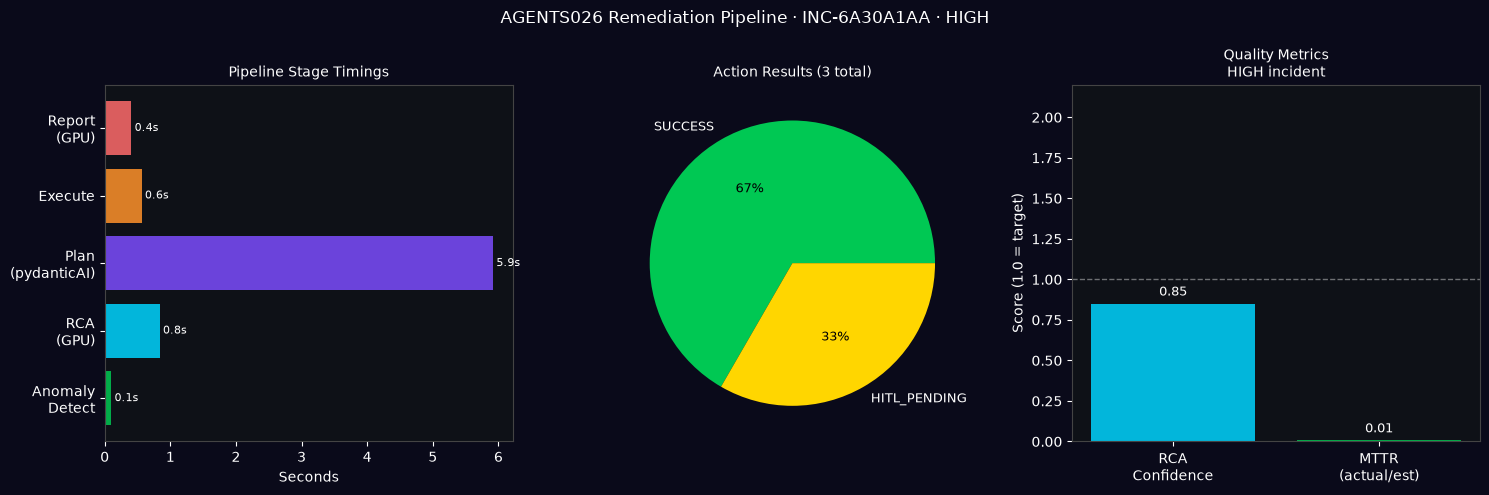

✅ Dashboard saved → /workspace/shared/remediation_pipeline_plot.png


In [14]:
# ── Cell 8: Results dashboard ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PIPELINE_PLOT = BASE / "remediation_pipeline_plot.png"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#0a0a1a")

# Plot 1: Pipeline stage timings
ax = axes[0]; ax.set_facecolor("#0e1117")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")
stages   = ["Anomaly\nDetect", "RCA\n(GPU)", "Plan\n(pydanticAI)", "Execute", "Report\n(GPU)"]
timings  = [0.1, rca_time, plan_time, sum(r.duration_ms for r in action_results)/1000, report_time]
colors_s = ["#00c853","#00d4ff","#7c4dff","#ff922b","#ff6b6b"]
bars = ax.barh(stages, timings, color=colors_s, alpha=0.85)
for bar, t in zip(bars, timings):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{t:.1f}s", va="center", color="white", fontsize=8)
ax.set_title("Pipeline Stage Timings", color="white", fontsize=10)
ax.set_xlabel("Seconds", color="white")

# Plot 2: Action status breakdown
ax2 = axes[1]; ax2.set_facecolor("#0e1117")
statuses = {"SUCCESS":0, "HITL_PENDING":0, "FAILED":0, "SKIPPED":0}
for r in action_results: statuses[r.status] = statuses.get(r.status,0) + 1
non_zero = {k:v for k,v in statuses.items() if v > 0}
status_colors = {"SUCCESS":"#00c853","HITL_PENDING":"#ffd600","FAILED":"#ff1744","SKIPPED":"#aaaaaa"}
if non_zero:
    wedges, texts, autotexts = ax2.pie(
        non_zero.values(), labels=non_zero.keys(), autopct="%1.0f%%",
        colors=[status_colors[k] for k in non_zero],
        textprops={"color":"white","fontsize":9}
    )
    for at in autotexts: at.set_color("black")
ax2.set_title(f"Action Results ({len(action_results)} total)", color="white", fontsize=10)
ax2.set_facecolor("#0e1117")

# Plot 3: RCA confidence + MTTR
ax3 = axes[2]; ax3.set_facecolor("#0e1117")
ax3.tick_params(colors="white")
for spine in ax3.spines.values(): spine.set_edgecolor("#444")
metrics_bar = ["RCA\nConfidence", "MTTR\n(actual/est)"]
vals_bar    = [rca.confidence, min(report.mttr_actual_mins / max(rca.estimated_mttr_mins,1), 2.0)]
colors_b    = ["#00d4ff" if rca.confidence > 0.7 else "#ffd600",
               "#00c853" if report.mttr_actual_mins <= rca.estimated_mttr_mins else "#ff6b6b"]
ax3.bar(metrics_bar, vals_bar, color=colors_b, alpha=0.85)
ax3.axhline(1.0, color="white", linestyle="--", linewidth=1, alpha=0.4)
ax3.set_ylim(0, 2.2)
ax3.set_title(f"Quality Metrics\n{rca.severity.value} incident", color="white", fontsize=10)
ax3.set_ylabel("Score (1.0 = target)", color="white")
for i, (label, val) in enumerate(zip(metrics_bar, vals_bar)):
    ax3.text(i, val + 0.05, f"{val:.2f}", ha="center", color="white", fontsize=9)

plt.suptitle(f"AGENTS026 Remediation Pipeline · {incident_id} · {rca.severity.value}",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig(str(PIPELINE_PLOT), dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Dashboard saved → {PIPELINE_PLOT}")